# Clustering - Data Science Portfolio - Mai Bui

In [ ]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D 


from sklearn.discriminant_analysis import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from collections import Counter
import time


import json

import ollama

In [ ]:
df = pd.read_csv("datasets/clustering_dataset.csv")

In [2]:
df.info()
print()
print(f"Missing values: {df.isnull().sum()[df.isnull().sum() > 0].sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130663 entries, 0 to 130662
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artist_name       130663 non-null  object 
 1   track_id          130663 non-null  object 
 2   track_name        130662 non-null  object 
 3   acousticness      130663 non-null  float64
 4   danceability      130663 non-null  float64
 5   duration_ms       130663 non-null  int64  
 6   energy            130663 non-null  float64
 7   instrumentalness  130663 non-null  float64
 8   key               130663 non-null  int64  
 9   liveness          130663 non-null  float64
 10  loudness          130663 non-null  float64
 11  mode              130663 non-null  int64  
 12  speechiness       130663 non-null  float64
 13  tempo             130663 non-null  float64
 14  time_signature    130663 non-null  int64  
 15  valence           130663 non-null  float64
 16  popularity        13

In [3]:
df.dropna(inplace=True)
df.describe()

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
count,130662.000000,130662.000000,1.306620e+05,130662.000000,130662.000000,130662.000000,130662.000000,130662.000000,130662.000000,130662.000000,130662.000000,130662.000000,130662.000000,130662.000000
mean,0.342500,0.581467,2.126336e+05,0.569197,0.224020,5.231896,0.194887,-9.973973,0.607744,0.112016,119.473579,3.878985,0.439632,24.208990
std,0.345642,0.190077,1.231554e+05,0.260312,0.360329,3.602715,0.167734,6.544393,0.488255,0.124327,30.159641,0.514405,0.259079,19.713266
min,0.000000,0.000000,3.203000e+03,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.031600,0.459000,1.639270e+05,0.396000,0.000000,2.000000,0.097500,-11.898000,0.000000,0.038900,96.014000,4.000000,0.224000,7.000000
50%,0.203000,0.605000,2.019030e+05,0.603000,0.000149,5.000000,0.124000,-7.979000,1.000000,0.055900,120.027000,4.000000,0.420000,22.000000
75%,0.636000,0.727000,2.410488e+05,0.775000,0.440000,8.000000,0.236000,-5.684000,1.000000,0.129000,139.642000,4.000000,0.638000,38.000000
max,0.996000,0.996000,5.610020e+06,1.000000,1.000000,11.000000,0.999000,1.806000,1.000000,0.966000,249.983000,5.000000,1.000000,100.000000


# Preprocessing

We use the 8 core continuous audio features and intentionally exclude:
- key, mode, time_signature — these are categorical integers (e.g. key 0–11), not continuous measurements.
- duration_ms — highly variable and not a meaningful descriptor of musical style.
- popularity — this is an external engagement metric, not an intrinsic audio feature.

In [ ]:
# Features selected for clustering

cluster_features = [
    'acousticness', 'danceability', 'energy',
    'instrumentalness', 'liveness', 'loudness',
    'speechiness', 'valence'
]

X = df[cluster_features]

# Standardize the features to have mean=0 and std=1 for better clustering performance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Correlation

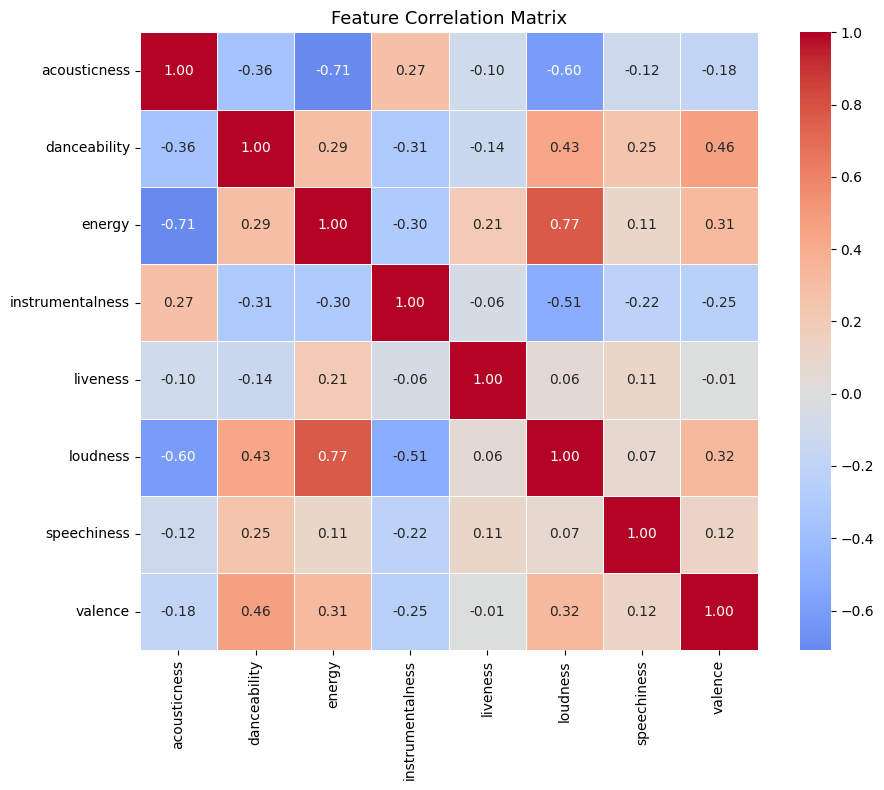

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[cluster_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

As there are high correlations between features, it might be harder to have definate, clear seperated clusters.

# Clustering

In [ ]:
# Sample for elbow/silhouette computation
np.random.seed(42) #so that random choices are reproducible (same sample and same results every time)
sample_idx = np.random.choice(len(X_scaled), size=20000, replace=False)
X_sample = X_scaled[sample_idx]

k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_sample) # learn centroids using X_sample (fit) and assign cluster labels to X_sample (predict)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_sample, labels, sample_size=5000, random_state=42))
    print(f'k={k}  inertia={km.inertia_:,.0f}  silhouette={silhouette_scores[-1]:.4f}')

k=2  inertia=114,084  silhouette=0.3325
k=3  inertia=100,554  silhouette=0.2283
k=4  inertia=89,369  silhouette=0.2334
k=5  inertia=80,374  silhouette=0.1950
k=6  inertia=72,923  silhouette=0.2229
k=7  inertia=66,458  silhouette=0.1976
k=8  inertia=63,517  silhouette=0.1770
k=9  inertia=60,880  silhouette=0.1741
k=10  inertia=58,787  silhouette=0.1747


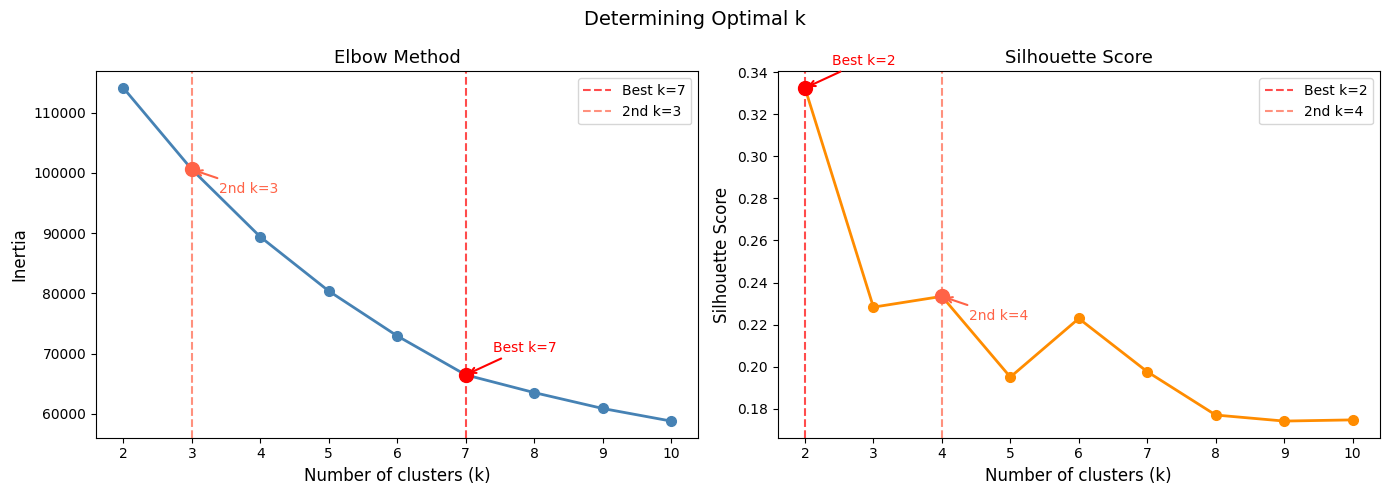

Elbow:      best k=7,  second best k=3
Silhouette: best k=2,  second best k=4


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
k_list = list(k_range)

def annotate_point(ax, k, score, label, color, y_range, direction=1):
    ax.axvline(k, color=color, linestyle='--', linewidth=1.5, alpha=0.7, label=label)
    ax.scatter([k], [score], color=color, zorder=5, s=100)
    ax.annotate(label,
                xy=(k, score),
                xytext=(k + 0.4, score + direction * y_range * 0.07),
                fontsize=10, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# Elbow: detect knee via second derivative
inertia_arr = np.array(inertias)
d2 = np.diff(np.diff(inertia_arr))
best_elbow_idx = np.argmax(d2) + 1 # +1 offset because d2 is 2 shorter than original inertia list
best_elbow_k = k_list[best_elbow_idx]

d2_masked = d2.copy()
d2_masked[best_elbow_idx - 1] = -np.inf   # mask out best (+1 offset applied)
second_elbow_idx = np.argmax(d2_masked) + 1
second_elbow_k = k_list[second_elbow_idx]

inertia_range = max(inertias) - min(inertias)

ax1.plot(k_list, inertias, 'o-', color='steelblue', linewidth=2, markersize=7)
annotate_point(ax1, best_elbow_k,   inertias[best_elbow_idx],   f'Best k={best_elbow_k}',   'red',    inertia_range,  1)
annotate_point(ax1, second_elbow_k, inertias[second_elbow_idx], f'2nd k={second_elbow_k}',  'tomato', inertia_range, -1)
ax1.set_xlabel('Number of clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=13)
ax1.set_xticks(k_list)
ax1.legend(fontsize=10)

# Silhouette: top two peaks
sil_arr = np.array(silhouette_scores)
best_sil_idx = np.argmax(sil_arr)
best_sil_k = k_list[best_sil_idx]

sil_masked = sil_arr.copy()
sil_masked[best_sil_idx] = -np.inf
second_sil_idx = np.argmax(sil_masked)
second_sil_k = k_list[second_sil_idx]

sil_range = max(silhouette_scores) - min(silhouette_scores)

ax2.plot(k_list, silhouette_scores, 'o-', color='darkorange', linewidth=2, markersize=7)
annotate_point(ax2, best_sil_k,   sil_arr[best_sil_idx],   f'Best k={best_sil_k}',  'red',    sil_range,  1)
annotate_point(ax2, second_sil_k, sil_arr[second_sil_idx], f'2nd k={second_sil_k}', 'tomato', sil_range, -1)
ax2.set_xlabel('Number of clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=13)
ax2.set_xticks(k_list)
ax2.legend(fontsize=10)

plt.suptitle('Determining Optimal k', fontsize=14)
plt.tight_layout()
plt.show()

print(f'Elbow:      best k={best_elbow_k},  second best k={second_elbow_k}')
print(f'Silhouette: best k={best_sil_k},  second best k={second_sil_k}')

We opt for k=4 as it seems like a good compromise between both measures.

## K-mean implementation

In [19]:
K = 4

kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster sizes:')
print(df['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0    19147
1    14307
2    27076
3    70132
Name: count, dtype: int64


In [ ]:
# PCA on the full scaled data

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PC1 explains {explained[0]*100:.1f}% of variance')
print(f'PC2 explains {explained[1]*100:.1f}% of variance')
print(f'Total: {sum(explained)*100:.1f}%')

PC1 explains 39.5% of variance
PC2 explains 15.5% of variance
Total: 55.0%


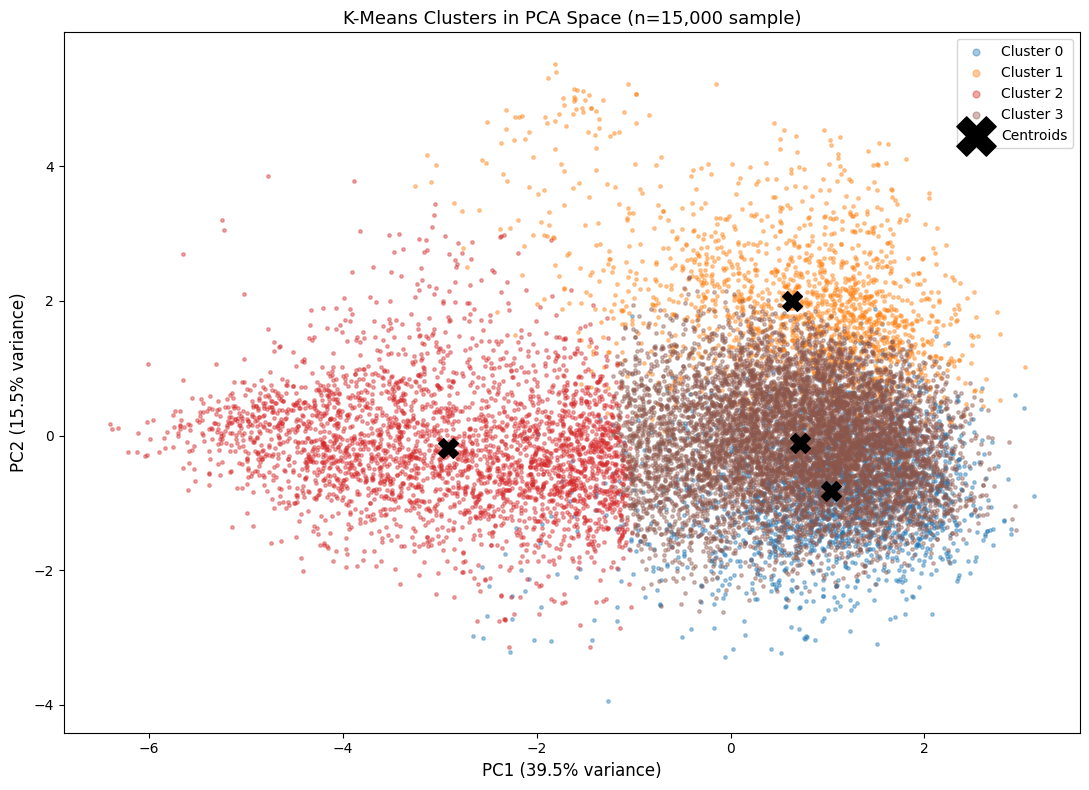

In [ ]:

# Plot a random sample of 15,000 points (full dataset is too dense)
plot_idx = np.random.choice(len(X_pca), size=15000, replace=False)
colors = cm.tab10(np.linspace(0, 0.5, K))

fig, ax = plt.subplots(figsize=(11, 8))

for c in range(K):
    mask = df['cluster'].values[plot_idx] == c
    ax.scatter(
        X_pca[plot_idx][mask, 0],
        X_pca[plot_idx][mask, 1],
        s=6, alpha=0.4, color=colors[c], label=f'Cluster {c}'
    )

# Plot cluster centroids in PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           s=200, c='black', marker='X', zorder=5, label='Centroids')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('K-Means Clusters in PCA Space (n=15,000 sample)', fontsize=13)
ax.legend(markerscale=2, fontsize=10)
plt.tight_layout()
plt.show()

The chart shows the results of a K-Means algorithm that grouped the songs into 4 clusters, visualized in 2D using PCA, which compressed the original data into two axes that together explain about 55% of the total variance. 

The most notable observation is that three of the four clusters (blue, orange, and gray) overlap heavily in the center-right region of the plot, meaning the algorithm is struggling to find clean boundaries between them. 

I will graph PC3 for a clearer picture.

In [ ]:

# PCA on the full scaled data

pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
print(f'PC1 explains {explained[0]*100:.1f}% of variance')
print(f'PC2 explains {explained[1]*100:.1f}% of variance')
print(f'PC3 explains {explained[2]*100:.1f}% of variance')
print(f'Total: {sum(explained)*100:.1f}%')

PC1 explains 39.5% of variance
PC2 explains 15.5% of variance
PC3 explains 13.4% of variance
Total: 68.4%


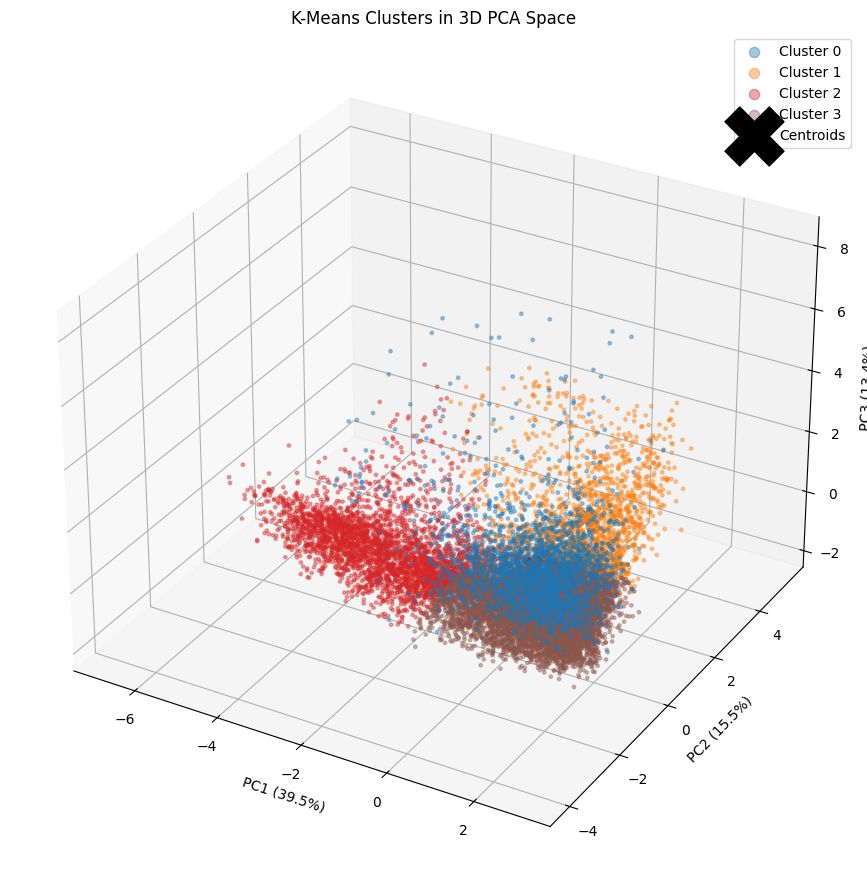

In [ ]:
# Sample for performance (optional but recommended for large datasets)
plot_idx = np.random.choice(len(X_pca), size=15000, replace=False)
colors = cm.tab10(np.linspace(0, 0.5, K))

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

for c in range(K):
    mask = df['cluster'].values[plot_idx] == c
    ax.scatter(
        X_pca[plot_idx][mask, 0],
        X_pca[plot_idx][mask, 1],
        X_pca[plot_idx][mask, 2],   # ← the 3rd PCA component
        s=6, alpha=0.4, color=colors[c], label=f'Cluster {c}'
    )

# Plot cluster centroids projected into PCA space
centroids_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    centroids_pca[:, 2],
    s=200, marker='X', color='black', zorder=100, label='Centroids'
)

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({explained[2]*100:.1f}%)')
ax.set_title('K-Means Clusters in 3D PCA Space')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

Adding a third axis (PC3) captures an additional 13.4% of variance, bringing the total explained variance to about 68%. 

The extra dimension help see some vertical separation between clusters, particularly with orange (Cluster 1) sitting higher on the PC3 axis compared to blue (Cluster 0) and gray (Cluster 3) which are flatter toward the bottom. However, blue, orange, and gray still overlap heavily in the center-right region, and no amount of added dimensions seems to cleanly separate them. 

This means that there are a lot of overlapping features between different songs, making it hard to seperate them into clear clusteres.

In [ ]:
def plot_mean_all_feature(X, cluster_labels):
    # Calculate means and standard deviations by cluster
    columns = list(X.columns)
    clusters = np.unique(cluster_labels)
    mean_ratios = []
    std_devs = []
    
    for cluster in clusters:
        cluster_data = X[cluster_labels == cluster]
        means = cluster_data.mean(axis=0)
        total_means = X.mean(axis=0)
        stds = cluster_data.std(axis=0,ddof=1)
        total_std = X.std(axis=0,ddof=1)
        mean_ratios.append((means - total_means)/total_std)  # Normalize
        std_devs.append(stds/total_std)
    
    # Plot
    x = np.arange(len(columns))
    width = 0.1  # Adjust as needed
    colors = ['red', 'green', 'blue', 'black', 'yellow', 'orange', 'purple', 'pink', 'brown', 'gray']
    
    plt.figure(figsize=(12, 6))

    for i, cluster in enumerate(clusters):
        plt.errorbar(
            x + i * width,
            mean_ratios[i],
            yerr=std_devs[i],
            fmt='o',
            label=f'Cluster {cluster}',
            color=colors[i]
        )
    
    plt.xticks(x, columns, rotation=45, ha='right')
    plt.ylabel('Normalized Mean (with Std Dev)')
    #plt.ylim(-5,5)
    plt.title('Cluster Features Analysis')
    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


Algorithm found 4 clusters.
Points per cluster: Counter({np.int32(1): 65787, np.int32(3): 41930, np.int32(0): 16068, np.int32(2): 6877})
Silhouette Score: 0.526111918373368



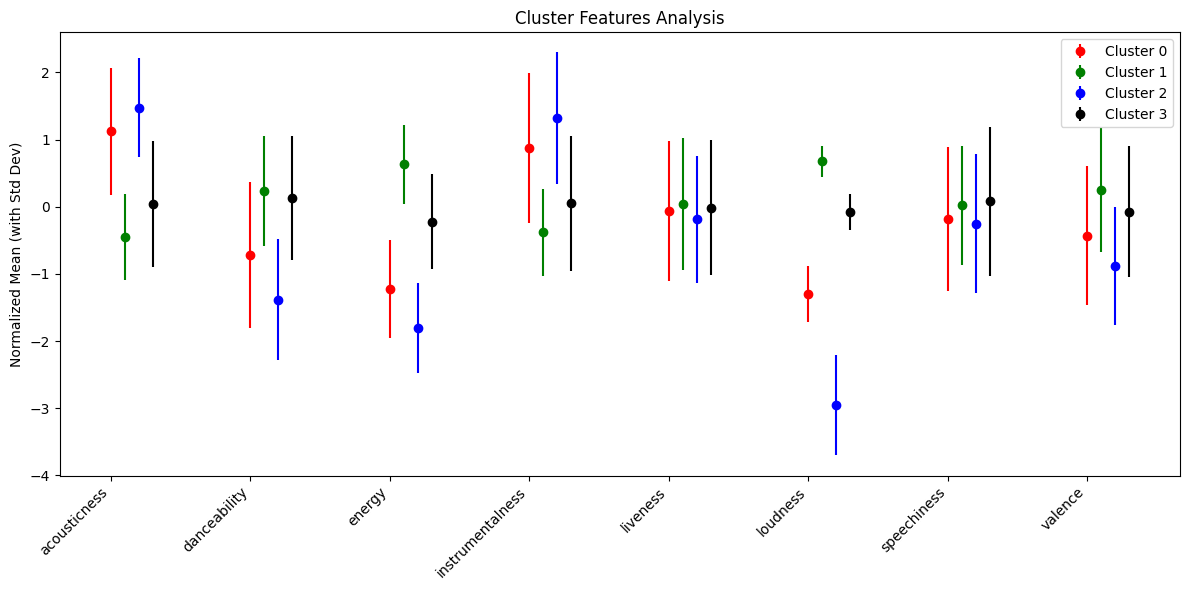

In [ ]:
# KMeans crucial parameters: n_clusters, init, n_init, max_iter, random_state
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X)
cluster_labels = kmeans.labels_

cluster_counts = Counter(cluster_labels)
print(f"Algorithm found {len(cluster_counts)} clusters.")
print("Points per cluster:", cluster_counts)

# Silhouette Score
print(f"Silhouette Score: {silhouette_score(X, cluster_labels)}\n")

# Plot true labels vs. clustering results
plot_mean_all_feature(X,cluster_labels)

Loudness (followed by energy, acousticness, and instrumetnalness) seem to be the most distinctive features for the clusters, which liveness and balence do not really differ by clusters.

# Trying to understand the clusters

I made an assumption that the clusters are different music genre. To check this, I ask Olama to label the genres of the some of the songs from each cluster and see if there are any parterns.

In [18]:
# getting sample from each cluster
samples = []

for c in range(K):
    sample = df[df['cluster'] == c][['artist_name', 'track_name']].sample(10)
    sample['cluster'] = c
    samples.append(sample)

samples_df = pd.concat(samples, ignore_index=True)

In [ ]:
PROMPT = """You are a music genre expert. Given an artist name and track name, return ONLY a JSON object with two fields: 'genre' and 'subgenre'. 
No explanation, no markdown, just raw JSON like: {"genre": "Hip-Hop", "subgenre": "Trap"}"""

def get_genre(artist, track):
    response = ollama.chat(model='llama3.2', messages=[
        {
            'role': 'user',
            'content': f'{PROMPT}\n\nArtist: {artist}\nTrack: {track}',
        },
    ])
    return response['message']['content']

# Save original persistently
samples_df['genre'] = None
samples_df['subgenre'] = None
samples_df.to_csv('samples_labeled.csv.gz', compression='gzip', index=False)

i = 0
while True:
    # Find all unprocessed rows
    left = samples_df.loc[samples_df['genre'].isna()]

    if len(left) == 0:
        print("All done!")
        break

    # Take a random unprocessed row
    line = left.sample()
    index = line.index.values[0]
    artist = line['artist_name'].values[0]
    track = line['track_name'].values[0]

    if i % 10 == 0:
        print(f"{len(left)} left to process. Processing index {index}: {artist} — {track}")

    # Get genre from local LLM
    result = get_genre(artist, track)
    
    # Parse JSON response safely
    try:
        parsed = json.loads(result)
        samples_df.loc[index, 'genre'] = parsed.get('genre', 'unknown')
        samples_df.loc[index, 'subgenre'] = parsed.get('subgenre', 'unknown')
    except json.JSONDecodeError:
        print(f"Could not parse response for {artist} — {track}: {result}")
        samples_df.loc[index, 'genre'] = 'parse_error'
        samples_df.loc[index, 'subgenre'] = 'parse_error'

    i += 1
    # Save progress after every row
    samples_df.to_csv('samples_labeled.csv.gz', compression='gzip', index=False)
    samples_df

40 left to process. Processing index 39: Divide — Victory (Fortnite)
30 left to process. Processing index 26: soho — At Peace
20 left to process. Processing index 13: Eagles — Outlaw Man - Remastered
10 left to process. Processing index 23: Jozezo Libra — Doctor Stoughton
All done!


Here is the df with sample songs from each clustered labeled:

In [20]:
samples_df

,artist_name,track_name,cluster,genre,subgenre
0,Higher Brothers,Gong Xi Fa Cai,0,Hip-Hop,Gangsta Rap
1,invention_,Dxy_Drmng,0,Electronic,Industrial
2,Dorm XO,Pull Strings,0,Emo Rap,Lo-Fi
3,Wifisfuneral,Can't Feel My Face,0,Emo Trap,Melodic
4,Sosamann,Light Bulb (feat. Sauce Walka),0,Trap,Hard Trap
5,Ubylis Da Plug,Stop,0,Hip-Hop,Trap
6,Splash Daddy,Wii Tennis,0,Electronic,Dance-Pop
7,Dee Wile,Monday,0,Rap,Gangsta Rap
8,SVDDEN DEATH,Rock Like This - oddprophet Remix,0,Dubstep,Riddim
9,RAFFY017,017 Bitch,0,Rap,Mafioso


From the table above and image below, the clusters does not reveal much about either the genre or popularity of a song (see the graph below). This makes sense because while the provided features, energy, instrumentalness, key, liveness, loudness, mode, speechiness, tempo, time_signature, and valence, can provide clusters that gives a lead on what the genre is, they are not the only features that is used to categorise music. Other factors like  "musical elements (e.g rhythm, melody, harmony, timbre, texture, form, or style), by instruments (e.g guitar, piano, drums, violin, saxophone, or synthesizers) by themes (e.g love, protest, party, religion, or politics) or by cultural origins (e.g country, region, ethnicity, language, or history)" ([source](https://www.startle.io/blog/music-genres-explained)) are more common in classfying music genre- which is not captured by the data. As such, while some clusters have similar (sounding) genres, overall, the clusters are not indicative of the music genre. Similarly, popularity may be influence by outside factors, such as how popular the artist already is, ads campaigns, genre, etc. which also is not included in the dataset.


/var/folders/p0/hrndsk2d7jzbhfc3__sry99r0000gn/T/ipykernel_10752/4120267640.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cluster', y='popularity', palette='tab10', ax=ax)


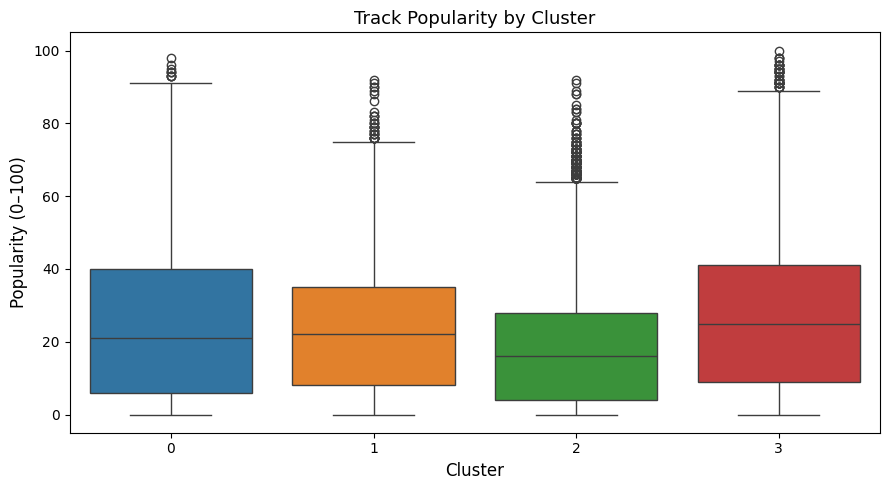

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x='cluster', y='popularity', palette='tab10', ax=ax)
ax.set_title('Track Popularity by Cluster', fontsize=13)
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Popularity (0–100)', fontsize=12)
plt.tight_layout()
plt.show()